In [1]:
import sys
from pathlib import Path

# Add the src directory to sys.path
sys.path.append(str(Path().resolve().parents[1] / "src"))

from datasource.gbif import sql
from cube import bmd

import openeo
import openeo.processes as proc

INFO:Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:NumExpr defaulting to 16 threads.


<div style="float: center; width: 100%; margin-left: 15px; text-align: center;">
  <img src="img/spatial_extent.png" alt="Test area of interest" style="width:100%;">
  <div style="font-size: 90%; color: gray; margin-top: 4px;">
    <em>Figure 1:</em> Spatial region of Belgium utilized in the demonstration of the cubing functionality
  </div>
</div>

In [ ]:
spatial_extent = [3.437072,50.638313,5.002624,51.461879]
temporal_extent = ["2019-01-01", "2019-01-31"]

# CHELSA Cubing demonstration

In [11]:
from utils.chelsa import extract_param

extract_param.read_chelsa_clim_sim_month_param("param_techDemo.yaml", "../../config")

{'var': ['tas', 'tasmin'],
 'bbox': (3.510132, 50.675576, 4.795532, 51.455718),
 'year_ranges': ['2011-2040', '2041-2070'],
 'months': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 'model_names': ['gfdl-esm4', 'ipsl-cm6a-lr'],
 'scenarios': ['ssp126', 'ssp370'],
 'base_url': 'https://os.zhdk.cloud.switch.ch/chelsav2/GLOBAL/climatologies',
 'version': 'V.2.1'}

In [2]:
techDemo_cube = bmd.bmd_cube()
techDemo_cube.generate_bmd_data("param_techDemo.yaml", "../../config")
techDemo_cube.construct_datatree()

{'var': ['clt', 'cmi', 'hurs', 'pet', 'pr', 'rsds', 'sfcWind', 'tas', 'tasmax', 'tasmin', 'vpd'], 'bbox': (3.510132, 50.675576, 4.795532, 51.455718), 'start_month': 1, 'end_month': 12, 'start_year': 2018, 'end_year': 2018, 'base_url': 'https://os.zhdk.cloud.switch.ch/chelsav2/GLOBAL/monthly', 'version': 'V.2.1'}
-----Retrieving monthly CHELSA data for variable 'clt'-----
-----Retrieving monthly CHELSA data for variable 'cmi'-----
-----Retrieving monthly CHELSA data for variable 'hurs'-----
-----Retrieving monthly CHELSA data for variable 'pet'-----
-----Retrieving monthly CHELSA data for variable 'pr'-----
-----Retrieving monthly CHELSA data for variable 'rsds'-----
-----Retrieving monthly CHELSA data for variable 'sfcWind'-----
-----Retrieving monthly CHELSA data for variable 'tas'-----
-----Retrieving monthly CHELSA data for variable 'tasmax'-----
-----Retrieving monthly CHELSA data for variable 'tasmin'-----
-----Retrieving monthly CHELSA data for variable 'vpd'-----
-----Retrieving

-----Retrieving Simulation (period) CHELSA data for variable 'scd'-----
-----Retrieving Simulation (period) CHELSA data for variable 'swe'-----
-----Retrieving Simulation (monthly) CHELSA data for variable 'tas'----------Retrieving Simulation (monthly) CHELSA data for variable 'tasmin'-----



INFO:GDAL signalled an error: err_no=1, msg='Request for 33225111-34377243 failed with response_code=206'


In [8]:
chelsa_datatree = techDemo_cube.data_tree
chelsa_datatree

<xarray.DataTree 'techDemo'>
Group: /
├── Group: /static
│   ├── Group: /static/chelsa_clim_ref_period
│   │       Dimensions:           (lat: 94, long: 154)
│   │       Coordinates:
│   │         * lat               (lat) float64 752B 51.45 51.44 51.43 ... 50.69 50.68 50.68
│   │         * long              (long) float64 1kB 3.514 3.523 3.531 ... 4.773 4.781 4.789
│   │       Data variables: (12/76)
│   │           ai                (lat, long) float32 58kB -1e+05 -1e+05 ... 1.227 1.222
│   │           bio10             (lat, long) uint16 29kB 2902 2902 2902 ... 2901 2901 2902
│   │           bio11             (lat, long) uint16 29kB 2777 2776 2776 ... 2762 2763 2763
│   │           bio12             (lat, long) uint16 29kB 8511 8516 8518 ... 8667 8652 8620
│   │           bio13             (lat, long) uint16 29kB 903 903 903 902 ... 803 801 797
│   │           bio14             (lat, long) uint16 29kB 447 448 448 448 ... 529 528 527
│   │           ...                ...
│   │           swb               (lat, long) int16 29kB -32768 -32768 -32768 ... -67 -64
│   │           swe               (lat, long) uint16 29kB 65535 65535 65535 ... 65535 65535
│   │           vpd_max           (lat, long) uint16 29kB 7879 7879 7883 ... 7909 7946 7962
│   │           vpd_mean          (lat, long) uint16 29kB 4989 4991 4992 ... 4748 4762 4775
│   │           vpd_min           (lat, long) uint16 29kB 2755 2752 2747 ... 2361 2365 2372
│   │           vpd_range         (lat, long) uint16 29kB 5124 5127 5136 ... 5548 5581 5590
│   ├── Group: /static/chelsa_clim_ref_month
│   │       Dimensions:  (months: 12, lat: 94, long: 154)
│   │       Coordinates:
│   │         * months   (months) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
│   │         * lat      (lat) float64 752B 51.45 51.44 51.43 51.43 ... 50.69 50.68 50.68
│   │         * long     (long) float64 1kB 3.514 3.523 3.531 3.539 ... 4.773 4.781 4.789
│   │       Data variables:
│   │           clt      (months, lat, long) float64 1MB 4.898e+03 4.898e+03 ... 5.658e+03
│   │           cmi      (months, lat, long) int16 347kB 219 222 229 286 ... 504 497 501 502
│   │           hurs     (months, lat, long) uint16 347kB 6705 6706 6708 ... 6999 6998 6995
│   │           pet      (months, lat, long) uint16 347kB 4466 4442 4375 ... 2703 2644 2592
│   │           pr       (months, lat, long) uint16 347kB 693 693 693 694 ... 803 801 797
│   │           rsds     (months, lat, long) uint16 347kB 2955 2956 2954 ... 2250 2255 2256
│   │           sfcWind  (months, lat, long) uint16 347kB 8242 8161 8013 ... 5638 5535 5426
│   │           tas      (months, lat, long) uint16 347kB 2774 2773 2773 ... 2766 2766 2766
│   │           tasmax   (months, lat, long) uint16 347kB 2791 2791 2791 ... 2788 2788 2788
│   │           tasmin   (months, lat, long) uint16 347kB 2754 2754 2754 ... 2743 2744 2744
│   │           vpd      (months, lat, long) uint16 347kB 2755 2752 2747 ... 2361 2365 2372
│   ├── Group: /static/chelsa_clim_sim_period
│   │       Dimensions:          (year_range: 3, model_name: 5, ensemble_member: 3,
│   │                             lat: 94, long: 154)
│   │       Coordinates:
│   │         * year_range       (year_range) <U9 108B '2011-2040' '2041-2070' '2071-2100'
│   │         * model_name       (model_name) <U13 260B 'gfdl-esm4' ... 'ukesm1-0-ll'
│   │         * ensemble_member  (ensemble_member) <U6 72B 'ssp126' 'ssp370' 'ssp585'
│   │         * lat              (lat) float64 752B 51.45 51.44 51.43 ... 50.69 50.68 50.68
│   │         * long             (long) float64 1kB 3.514 3.523 3.531 ... 4.773 4.781 4.789
│   │       Data variables: (12/46)
│   │           bio10            (year_range, model_name, ensemble_member, lat, long) uint16 1MB ...
│   │           bio11            (year_range, model_name, ensemble_member, lat, long) uint16 1MB ...
│   │           bio12            (year_range, model_name, ensemble_member, lat, long) uint16 1MB ...
│   │           bio13            (year_range, mod

# GBIF cubing demonstration 

In [15]:
bbox = sql.bbox2polygon_wkt((3.510132,50.675576,4.795532,51.455718))

#2 species Vespa Veluntina and Fallopia Japonica
occurrenceGridNA_techDemo = sql.generate_query([1311477, 5334357], 
                                               ["month", "year", "speciesKey", "countrycode", "gbifid"], 
                                               "occurrence", 
                                               bbox)
path = sql.download_query(occurrenceGridNA_techDemo, "techDemo_download")

✅ GBIF credentials are valid.
Credentials stored in C:\Users\niels\Documents\Repositories\BmC\scripts\technical_demonstration\.env.


RuntimeError: Failed to submit GBIF download: error: A download limitation is exceeded:
User nbilliet has too many simultaneous downloads; the limit is 3.
Please wait for some to complete, or cancel any unwanted downloads.  See your user page.
, with error status code 420check your number of active downloads.

# OpenEO cubing demonstration

In [3]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

In [13]:
spatial_extent = {"west":3.510132,"south":50.675576,"east":4.795532,"north":51.455718}
temporal_extent = ["2019-01-01", "2019-12-31"]

## Biological and soil index calculation

In [14]:
s2_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B11", "B12", "SCL"]
)

# 2. Mask Clouds (Keep Veg(4), Bare(5), Water(6))
scl = s2_cube.band("SCL")
clean_mask = (scl == 4) | (scl == 5) | (scl == 6)
s2_masked = s2_cube.mask(~clean_mask)

# 3. Resample & Gap Fill
# We downsample the entire data cube to 1km here, instead of doing it 12 times later.

s2_1km = s2_masked.resample_spatial(
    resolution=1000, 
    projection=3857, 
    method="bilinear"
)

# Apply linear interpolation on the smaller 1km cube
s2_filled = s2_1km.apply_dimension(process="array_interpolate_linear", dimension="t")


# 4. Scale to Reflectance (Using the new s2_filled cube)
bands_to_load = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B11", "B12"]
scaled = {b: s2_filled.band(b) * 0.0001 for b in bands_to_load}

# Define natural log transformation for individual cubes (NDLI requirements)
log_b11_neg = scaled["B11"].apply(lambda x: proc.ln(x) * -1)
log_b08_neg = scaled["B08"].apply(lambda x: proc.ln(x) * -1)

# 5. Calculate Indices
eps = 1e-6
min_ref = 0.01

indices = {
    # --- Standard Vegetation & Soil Indices ---
    "NDVI":  (scaled["B08"] - scaled["B04"]) / (scaled["B08"] + scaled["B04"] + eps),
    
    "EVI":   2.5 * (scaled["B08"] - scaled["B04"]) / (scaled["B08"] + 6.0 * scaled["B04"] - 7.5 * scaled["B02"] + 1.0 + eps),
    
    "MSAVI": (2 * scaled["B08"] + 1 - ((2 * scaled["B08"] + 1)**2 - 8 * (scaled["B08"] - scaled["B04"]))**0.5) / 2,

    # --- Red-Edge & Pigment Indices ---
    "NDRE":  (scaled["B08"] - scaled["B05"]) / (scaled["B08"] + scaled["B05"] + eps),
    
    "REIP":  705 + 35 * (((scaled["B04"] + scaled["B07"]) / 2) - scaled["B05"]) / (scaled["B06"] - scaled["B05"] + eps),
    
    "ARI": (
        (1 / (scaled["B03"] + eps)) - (1 / (scaled["B05"] + eps))
    ).mask(
        (scaled["B03"] < min_ref) | (scaled["B05"] < min_ref)
    ),
    
    "CRI": (
        (1 / (scaled["B02"] + eps)) - (1 / (scaled["B03"] + eps))
    ).mask(
        (scaled["B02"] < min_ref) | (scaled["B03"] < min_ref)
    ),

    "mARI": (
        ((1 / (scaled["B03"] + eps)) - (1 / (scaled["B05"] + eps))) * scaled["B08"]
    ).mask(
        (scaled["B03"] < min_ref) | (scaled["B05"] < min_ref)
    ),
    
    # mCRI: Modified Carotenoid Reflectance Index
    # Uses NIR (B08) to normalize
    "mCRI": (
        ((1 / (scaled["B02"] + eps)) - (1 / (scaled["B03"] + eps))) * scaled["B08"]
    ).mask(
        (scaled["B02"] < min_ref) | (scaled["B03"] < min_ref)
    ),
    
    # --- Water, Moisture & Disturbance ---
    "NDWI":  (scaled["B03"] - scaled["B08"]) / (scaled["B03"] + scaled["B08"] + eps),
    
    "NDMI":  (scaled["B08"] - scaled["B11"]) / (scaled["B08"] + scaled["B11"] + eps),
    
    "NBR":   (scaled["B08"] - scaled["B12"]) / (scaled["B08"] + scaled["B12"] + eps),

    # --- Functional Diversity Indices ---
    "FPAR":  (((scaled["B08"] - scaled["B04"]) / (scaled["B08"] + scaled["B04"] + eps)) * 1.25) - 0.1,
    
    "NDLI": (log_b11_neg - log_b08_neg) / (log_b11_neg + log_b08_neg + eps)
}

# 6. Process: Monthly Aggregation
bio_layers = []
for label, cube in indices.items():
    # Note: Gap fill and Resampling are removed from here as they are done above.
    
    # Aggregate to Month (Max value to avoid clouds/shadows)
    monthly_stat = cube.aggregate_temporal_period(period="month", reducer="max")
    
    # Labeling
    labeled_cube = monthly_stat.add_dimension(name="bands", label=label, type="bands")
    bio_layers.append(labeled_cube)

# 7. Merge to create the final Biodiversity Object
bio_master_cube = bio_layers[0]
for layer in bio_layers[1:]:
    bio_master_cube = bio_master_cube.merge_cubes(layer)

# 8. Submit Batch Job with Stability Options
print("Submitting Biodiversity Job...")
job_bio = bio_master_cube.execute_batch(
    out_format="NetCDF", 
    title="Bio_Master_1km_techDemo",
    job_options={
        "executor-memory": "10G",          # High RAM for masking operations
        "executor-memoryOverhead": "4G",   # Extra buffer for native code/shuffle
        "executor-cores": 1,               # Single core per executor to maximize RAM per task
        "driver-memory": "4G",
        "spark.sql.shuffle.partitions": "200" # Ensure data is broken into manageable chunks
    }
)

Submitting Biodiversity Job...
0:00:00 Job 'j-2601200844514083bc103ced12423059': send 'start'
0:00:19 Job 'j-2601200844514083bc103ced12423059': created (progress 0%)
0:00:24 Job 'j-2601200844514083bc103ced12423059': queued (progress 0%)
0:00:30 Job 'j-2601200844514083bc103ced12423059': queued (progress 0%)
0:00:38 Job 'j-2601200844514083bc103ced12423059': queued (progress 0%)
0:00:52 Job 'j-2601200844514083bc103ced12423059': queued (progress 0%)
0:01:08 Job 'j-2601200844514083bc103ced12423059': queued (progress 0%)
0:01:23 Job 'j-2601200844514083bc103ced12423059': running (progress N/A)
0:01:43 Job 'j-2601200844514083bc103ced12423059': running (progress N/A)
0:02:07 Job 'j-2601200844514083bc103ced12423059': running (progress N/A)
0:02:36 Job 'j-2601200844514083bc103ced12423059': running (progress N/A)
0:03:14 Job 'j-2601200844514083bc103ced12423059': running (progress N/A)
0:04:01 Job 'j-2601200844514083bc103ced12423059': running (progress N/A)
0:04:59 Job 'j-2601200844514083bc103ced12

In [17]:
job_bio

<BatchJob job_id='j-2601200844514083bc103ced12423059'>

In [16]:
results = job_bio.get_results()
results.download_files("bioSoil_techdemo")

[WindowsPath('bioSoil_techdemo/openEO.nc'),
 WindowsPath('bioSoil_techdemo/job-results.json')]

## Cube analysis

In [19]:
import xarray as xr

bioSoil_cube = xr.open_dataset("bioSoil_techdemo/openEO.nc", engine="netcdf4")
bioSoil_cube

<xarray.Dataset> Size: 12MB
Dimensions:  (t: 12, x: 145, y: 139)
Coordinates:
  * t        (t) datetime64[ns] 96B 2019-01-01 2019-02-01 ... 2019-12-01
  * x        (x) float64 1kB 3.903e+05 3.913e+05 ... 5.333e+05 5.343e+05
  * y        (y) float64 1kB 6.702e+06 6.701e+06 6.7e+06 ... 6.565e+06 6.564e+06
Data variables: (12/13)
    crs      |S1 1B ...
    NDVI     (t, y, x) float32 967kB ...
    EVI      (t, y, x) float32 967kB ...
    MSAVI    (t, y, x) float32 967kB ...
    NDRE     (t, y, x) float32 967kB ...
    REIP     (t, y, x) float32 967kB ...
    ...       ...
    CRI      (t, y, x) float32 967kB ...
    NDWI     (t, y, x) float32 967kB ...
    NDMI     (t, y, x) float32 967kB ...
    NBR      (t, y, x) float32 967kB ...
    FPAR     (t, y, x) float32 967kB ...
    NDLI     (t, y, x) float32 967kB ...
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.70.0a7.dev20...
    description:  
    title:

## Fractional landcover 

In [67]:
lc_window  = ["2021-01-01", "2021-12-31"]

lc_cube = connection.load_collection(
    "ESA_WORLDCOVER_10M_2021_V2",
    spatial_extent=spatial_extent, # Must allow covering the same area
    temporal_extent=lc_window
)

lc_classes = {
    "trees": 10,
    "shrubland": 20,
    "grassland": 30,
    "cropland": 40,
    "builtup": 50,
    "barren": 60,
    "snowIce": 70,
    "water": 80,
    "herbWetland":90,
    "mangroves":95,
    "mossLichen":100
}
lc_layers = []

for name, value in lc_classes.items():
    # 2. Binary Mask & Float Conversion
    # * 1.0 to prevent integer rounding to zero
    binary_class = (lc_cube.band("MAP") == value)
    float_mask = binary_class * 1.0 
    
    # 3. SPATIAL ALIGNMENT
    # We use 'resample_cube_spatial' to force this data into the bio_master_cube grid.
    # It copies the extent, resolution, and pixel alignment exactly.
    lc_aligned = float_mask.resample_cube_spatial(
        target=bio_master_cube, 
        method="average" # Returns fraction 0.0-1.0
    )
    
    # 4. Labeling
    labeled_lc = lc_aligned.add_dimension(
            name="bands", 
            label=name, 
            type="bands"
        )
    lc_layers.append(labeled_lc)

# 5. Merge Land Cover layers
lc_final_cube = lc_layers[0]
for layer in lc_layers[1:]:
    lc_final_cube = lc_final_cube.merge_cubes(layer)

In [68]:
print("Submitting LandCover Job...")
job_lc = lc_final_cube.execute_batch(out_format="NetCDF", title="LC_Aligned_1km_techDemo")

Submitting LandCover Job...
0:00:00 Job 'j-2601201055134d9f94886c885aa51bae': send 'start'
0:00:26 Job 'j-2601201055134d9f94886c885aa51bae': created (progress 0%)
0:00:31 Job 'j-2601201055134d9f94886c885aa51bae': created (progress 0%)
0:00:38 Job 'j-2601201055134d9f94886c885aa51bae': created (progress 0%)
0:00:46 Job 'j-2601201055134d9f94886c885aa51bae': created (progress 0%)
0:00:56 Job 'j-2601201055134d9f94886c885aa51bae': created (progress 0%)
0:01:09 Job 'j-2601201055134d9f94886c885aa51bae': running (progress N/A)
0:01:24 Job 'j-2601201055134d9f94886c885aa51bae': running (progress N/A)
0:01:44 Job 'j-2601201055134d9f94886c885aa51bae': running (progress N/A)
0:02:08 Job 'j-2601201055134d9f94886c885aa51bae': running (progress N/A)
0:02:38 Job 'j-2601201055134d9f94886c885aa51bae': running (progress N/A)
0:03:15 Job 'j-2601201055134d9f94886c885aa51bae': running (progress N/A)
0:04:02 Job 'j-2601201055134d9f94886c885aa51bae': running (progress N/A)
0:05:00 Job 'j-2601201055134d9f94886c8

In [73]:
job_lc

<BatchJob job_id='j-2601201055134d9f94886c885aa51bae'>

In [74]:
results = job_lc.get_results()
results.download_files("fracLandCover_techdemo")

[WindowsPath('fracLandCover_techdemo/openEO.nc'),
 WindowsPath('fracLandCover_techdemo/job-results.json')]

## Topographical indices

In [69]:
target_crs = 3857

def generate_topo_cube(connection, bio_master_cube, spatial_extent, target_crs):
    """
    Generates a 1km topography cube from a Lat/Lon input (EPSG:4326).
    1. Loads buffered area in Lat/Lon.
    2. Projects to UTM (Meters) for correct Slope/Aspect math.
    3. Crops cleanly to the bio_master_cube.
    """
    
# 1. PADDING (Handle 4326 input)
    pad = .3
    spatial_padded = {
        "west":  spatial_extent["west"] - pad, "east":  spatial_extent["east"] + pad,
        "south": spatial_extent["south"] - pad, "north": spatial_extent["north"] + pad,
        "crs":   4326
    }
    
    # 2. LOAD & REPROJECT TO METRIC (30m)
    # This aligns the DEM to the same CRS as bio_master_cube, but at high resolution
    dem = connection.load_collection("COPERNICUS_30", spatial_extent=spatial_padded).reduce_dimension(dimension="t", reducer="max")
    dem_resampled = dem.resample_spatial(resolution=30, projection=target_crs, method="bilinear")

    # ---------------------------------------------------------
    # 4. CALCULATE DERIVATIVES
    # ---------------------------------------------------------
    
    # Savitzky-Golay 7x7 Kernels
    sg_x = [
        [-3, -2, -1, 0, 1, 2, 3], [-3, -2, -1, 0, 1, 2, 3], [-3, -2, -1, 0, 1, 2, 3],
        [-3, -2, -1, 0, 1, 2, 3], [-3, -2, -1, 0, 1, 2, 3], [-3, -2, -1, 0, 1, 2, 3],
        [-3, -2, -1, 0, 1, 2, 3]
    ]
    sg_y = [[row[i] for row in sg_x] for i in range(7)]

    # Normalization for 30m pixels: 1 / (196 * 30)
    norm_factor = 1.0 / 5880.0

    dz_dx = dem_resampled.apply_kernel(kernel=sg_x, factor=norm_factor)
    dz_dy = dem_resampled.apply_kernel(kernel=sg_y, factor=norm_factor)

    # Slope (m/m) -> Degrees
    slope_rise_run = (
        dz_dx.apply(lambda x: proc.power(x, 2)) + 
        dz_dy.apply(lambda x: proc.power(x, 2))
    ).apply(lambda x: x.sqrt())
    
    # Try/Except for arctan safety
    try:
        slope_final = slope_rise_run.apply(lambda x: proc.arctan(x) * 57.2958)
    except:
        slope_final = slope_rise_run

    # Northness/Eastness (using Rise/Run Ratio)
    eps = 0.00001
    northness = dz_dy / (slope_rise_run + eps)
    eastness  = dz_dx / (slope_rise_run + eps)

    # Curvature (LoG 7x7)
    kernel_log_7x7 = [
        [0, 0, 1, 2, 1, 0, 0], [0, 1, 3, 8, 3, 1, 0], [1, 3, 0, -12, 0, 3, 1],
        [2, 8, -12, -45, -12, 8, 2], [1, 3, 0, -12, 0, 3, 1], [0, 1, 3, 8, 3, 1, 0], [0, 0, 1, 2, 1, 0, 0]
    ]
    curvature = dem_resampled.apply_kernel(kernel=kernel_log_7x7, factor=1/100.0)

    # Ruggedness
    dem_sq = dem_resampled.apply(lambda x: proc.power(x, 2))

    # ---------------------------------------------------------
    # 5. AGGREGATE TO 1KM & CROP
    # ---------------------------------------------------------
    # The resample step automatically crops the 10km buffer away.
    target = bio_master_cube
    
    layers = [
        dem_resampled.resample_cube_spatial(target, method="average").rename_labels("bands", ["elevation"]),
        slope_final.resample_cube_spatial(target, method="average").rename_labels("bands", ["slope"]),
        curvature.resample_cube_spatial(target, method="average").rename_labels("bands", ["curvature"]),
        northness.resample_cube_spatial(target, method="average").rename_labels("bands", ["northness"]),
        eastness.resample_cube_spatial(target, method="average").rename_labels("bands", ["eastness"]),
    ]
    
    # Ruggedness (SD)
    dem_sq_1km = dem_sq.resample_cube_spatial(target, method="average")
    elev_1km = layers[0]
    elev_sq_1km = elev_1km.apply(lambda x: proc.power(x, 2))
    ruggedness = (dem_sq_1km - elev_sq_1km).apply(lambda x: x.sqrt()).rename_labels("bands", ["ruggedness"])
    layers.append(ruggedness)

    # Merge
    final_cube = layers[0]
    for l in layers[1:]:
        final_cube = final_cube.merge_cubes(l)
            
    return final_cube

In [70]:
topo_cube = generate_topo_cube(connection, bio_master_cube, spatial_extent, target_crs)
topo_job = topo_cube.execute_batch("Topography_1km_techDemo.nc")

0:00:00 Job 'j-2601201211414f28bd2aedbdfdbb87ca': send 'start'
0:00:19 Job 'j-2601201211414f28bd2aedbdfdbb87ca': created (progress 0%)
0:00:24 Job 'j-2601201211414f28bd2aedbdfdbb87ca': created (progress 0%)
0:00:30 Job 'j-2601201211414f28bd2aedbdfdbb87ca': created (progress 0%)
0:00:38 Job 'j-2601201211414f28bd2aedbdfdbb87ca': running (progress N/A)
0:00:48 Job 'j-2601201211414f28bd2aedbdfdbb87ca': running (progress N/A)
0:01:01 Job 'j-2601201211414f28bd2aedbdfdbb87ca': running (progress N/A)
0:01:16 Job 'j-2601201211414f28bd2aedbdfdbb87ca': running (progress N/A)
0:01:35 Job 'j-2601201211414f28bd2aedbdfdbb87ca': running (progress N/A)
0:01:59 Job 'j-2601201211414f28bd2aedbdfdbb87ca': running (progress N/A)
0:02:29 Job 'j-2601201211414f28bd2aedbdfdbb87ca': running (progress N/A)
0:03:07 Job 'j-2601201211414f28bd2aedbdfdbb87ca': running (progress N/A)
0:03:53 Job 'j-2601201211414f28bd2aedbdfdbb87ca': running (progress N/A)
0:04:52 Job 'j-2601201211414f28bd2aedbdfdbb87ca': running (progr

In [76]:
topo_job

<BatchJob job_id='j-2601201211414f28bd2aedbdfdbb87ca'>

In [75]:
results = topo_job.get_results()
results.download_files("topographic_techdemo")

[WindowsPath('topographic_techdemo/openEO.nc'),
 WindowsPath('topographic_techdemo/job-results.json')]

In [78]:
connection.list_collection_ids()

['SENTINEL3_OLCI_L1B',
 'SENTINEL3_SLSTR',
 'SENTINEL_5P_L2',
 'LANDSAT8_L2_BIMONTHLY_MOSAIC',
 'COPERNICUS_VEGETATION_PHENOLOGY_PRODUCTIVITY_10M_SEASON1',
 'COPERNICUS_VEGETATION_PHENOLOGY_PRODUCTIVITY_10M_SEASON2',
 'COPERNICUS_PLANT_PHENOLOGY_INDEX',
 'ESA_WORLDCOVER_10M_2020_V1',
 'ESA_WORLDCOVER_10M_2021_V2',
 'SENTINEL2_L1C',
 'SENTINEL2_L2A',
 'SENTINEL1_GRD',
 'COPERNICUS_30',
 'LANDSAT8_L2',
 'SENTINEL3_SYN_L2_SYN',
 'SENTINEL3_SLSTR_L2_LST',
 'SENTINEL1_GLOBAL_MOSAICS',
 'SENTINEL3_OLCI_L2_LAND',
 'SENTINEL3_OLCI_L2_WATER',
 'SENTINEL3_SYN_L2_AOD']

In [77]:
connection.describe_collection("COPERNICUS_30")

{'cube:dimensions': {'bands': {'type': 'bands', 'values': ['DEM']},
  't': {'extent': ['2010-12-12T00:00:00Z', None], 'type': 'temporal'},
  'x': {'axis': 'x',
   'extent': [-180, 180],
   'step': 0.0002777777777777778,
   'type': 'spatial'},
  'y': {'axis': 'y',
   'extent': [-90, 90],
   'step': 0.0002777777777777778,
   'type': 'spatial'}},
 'description': 'Copernicus Global 30 meter Digital Elevation Model dataset.',
 'extent': {'spatial': {'bbox': [[-180, -90, 180, 90]]},
  'temporal': {'interval': [['2010-12-12T00:00:00Z', None]]}},
 'id': 'COPERNICUS_30',
 'license': 'proprietary',
 'links': [{'href': 'https://doi.org/10.5270/ESA-c5d3d65', 'rel': 'cite-as'},
  {'href': 'https://spacedata.copernicus.eu/documents/20123/121286/CSCDA_ESA_Mission-specific+Annex_31_Oct_22.pdf/fb109818-56ad-bbee-053c-d972aed25ce6?t=1674741175657',
   'rel': 'license',
   'type': 'application/pdf'},
  {'href': 'https://services.terrascope.be/wmts/v2',
   'rel': 'wmts',
   'wmts:layer': 'COP_DEM_GLO_30M_COG'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'root'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'parent'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections/COPERNICUS_30',
   'rel': 'self'}],
 'providers': [],
 'sci:doi': '10.5270/ESA-c5d3d65',
 'stac_extensions': ['https://stac-extensions.github.io/datacube/v2.2.0/schema.json',
  'https://stac-extensions.github.io/eo/v1.1.0/schema.json'],
 'stac_version': '0.9.0',
 'summaries': {'bands': [{'name': 'DEM'}], 'eo:bands': [{'name': 'DEM'}]},
 'title': 'Copernicus Global 30 meter Digital Elevation Model dataset.'}

In [80]:
germany_extent = {"west":5.690918,"south":47.279229,"east":15.117188,"north":55.065787}
pad=0.02
spatial_padded = {
        "west":  germany_extent["west"] - pad, "east":  germany_extent["east"] + pad,
        "south": germany_extent["south"] - pad, "north": germany_extent["north"] + pad,
        "crs":   4326
    }
 # 2. LOAD & REPROJECT TO METRIC (30m)
# This aligns the DEM to the same CRS as bio_master_cube, but at high resolution
dem = connection.load_collection("COPERNICUS_30", spatial_extent=spatial_padded).reduce_dimension(dimension="t", reducer="max")
dem_resampled = dem.resample_spatial(resolution=30, projection=target_crs, method="bilinear")

# ---------------------------------------------------------
# 4. CALCULATE DERIVATIVES (On Safe UTM Data)
# ---------------------------------------------------------

# Savitzky-Golay 7x7 Kernels
sg_x = [
    [-3, -2, -1, 0, 1, 2, 3], [-3, -2, -1, 0, 1, 2, 3], [-3, -2, -1, 0, 1, 2, 3],
    [-3, -2, -1, 0, 1, 2, 3], [-3, -2, -1, 0, 1, 2, 3], [-3, -2, -1, 0, 1, 2, 3],
    [-3, -2, -1, 0, 1, 2, 3]
]
sg_y = [[row[i] for row in sg_x] for i in range(7)]

# Normalization for 30m pixels: 1 / (196 * 30)
norm_factor = 1.0 / 5880.0

dz_dx = dem_resampled.apply_kernel(kernel=sg_x, factor=norm_factor)
dz_dy = dem_resampled.apply_kernel(kernel=sg_y, factor=norm_factor)

# Slope (m/m) -> Degrees
slope_rise_run = (
    dz_dx.apply(lambda x: proc.power(x, 2)) + 
    dz_dy.apply(lambda x: proc.power(x, 2))
).apply(lambda x: x.sqrt())

# Try/Except for arctan safety
try:
    slope_final = slope_rise_run.apply(lambda x: proc.arctan(x) * 57.2958)
except:
    slope_final = slope_rise_run

# Northness/Eastness (using Rise/Run Ratio)
eps = 0.00001
northness = dz_dy / (slope_rise_run + eps)
eastness  = dz_dx / (slope_rise_run + eps)

# Curvature (LoG 7x7)
kernel_log_7x7 = [
    [0, 0, 1, 2, 1, 0, 0], [0, 1, 3, 8, 3, 1, 0], [1, 3, 0, -12, 0, 3, 1],
    [2, 8, -12, -45, -12, 8, 2], [1, 3, 0, -12, 0, 3, 1], [0, 1, 3, 8, 3, 1, 0], [0, 0, 1, 2, 1, 0, 0]
]
curvature = dem_resampled.apply_kernel(kernel=kernel_log_7x7, factor=1/100.0)

average_kernel = [[1/9,1/9,1/9],
                  [1/9,1/9,1/9],
                  [1/9,1/9,1/9]]

mean_dem = dem_resampled.apply_kernel(kernel=average_kernel)
focalSum_deviation = (dem_resampled-mean_dem).apply(lambda x: proc.power(x, 2))
ruggedness = focalSum_deviation.apply_kernel(kernel=average_kernel).apply(lambda x: x.sqrt())

layers = [
        dem_resampled.resample_spatial(resolution=1000, projection=target_crs, method="average").rename_labels("bands", ["elevation"]),
        slope_final.resample_spatial(resolution=1000, projection=target_crs, method="average").rename_labels("bands", ["slope"]),
        curvature.resample_spatial(resolution=1000, projection=target_crs, method="average").rename_labels("bands", ["curvature"]),
        northness.resample_spatial(resolution=1000, projection=target_crs, method="average").rename_labels("bands", ["northness"]),
        eastness.resample_spatial(resolution=1000, projection=target_crs, method="average").rename_labels("bands", ["eastness"]),
        ruggedness.resample_spatial(resolution=1000, projection=target_crs, method="average").rename_labels("bands", ["ruggedness"])
    ]
topo_cube = layers[0]
for layer in layers[1:]:
    topo_cube= topo_cube.merge_cubes(layer)
topo_cube.execute_batch("germany_topographic.nc")

0:00:00 Job 'j-2601201453394e9c8621ddc6124fce88': send 'start'
0:00:23 Job 'j-2601201453394e9c8621ddc6124fce88': created (progress 0%)
0:00:29 Job 'j-2601201453394e9c8621ddc6124fce88': created (progress 0%)
0:00:35 Job 'j-2601201453394e9c8621ddc6124fce88': created (progress 0%)
0:00:43 Job 'j-2601201453394e9c8621ddc6124fce88': running (progress N/A)
0:00:59 Job 'j-2601201453394e9c8621ddc6124fce88': running (progress N/A)
0:01:11 Job 'j-2601201453394e9c8621ddc6124fce88': running (progress N/A)
0:01:27 Job 'j-2601201453394e9c8621ddc6124fce88': running (progress N/A)
0:01:46 Job 'j-2601201453394e9c8621ddc6124fce88': running (progress N/A)
0:02:10 Job 'j-2601201453394e9c8621ddc6124fce88': running (progress N/A)
0:02:40 Job 'j-2601201453394e9c8621ddc6124fce88': running (progress N/A)
0:03:17 Job 'j-2601201453394e9c8621ddc6124fce88': running (progress N/A)
0:04:04 Job 'j-2601201453394e9c8621ddc6124fce88': running (progress N/A)
0:05:02 Job 'j-2601201453394e9c8621ddc6124fce88': running (progr

<BatchJob job_id='j-2601201453394e9c8621ddc6124fce88'>

In [81]:
ls

 Volume in drive C is OS
 Volume Serial Number is 1C25-B250

 Directory of C:\Users\niels\Documents\Repositories\BmC\scripts\technical_demonstration

20/01/2026  16:15    <DIR>          .
19/01/2026  12:07    <DIR>          ..
20/01/2026  13:20    <DIR>          .ipynb_checkpoints
20/01/2026  11:37    <DIR>          bioSoil_techdemo
20/01/2026  13:33    <DIR>          fracLandCover_techdemo
20/01/2026  16:15         5.849.739 germany_topographic.nc
20/01/2026  16:13    <DIR>          img
20/01/2026  16:14           362.065 Technical Demonstration.ipynb
20/01/2026  13:33    <DIR>          topographic_techdemo
20/01/2026  13:23         2.026.063 Topography_1km_techDemo.nc
20/01/2026  15:06         3.844.851 Untitled.ipynb
               4 File(s)     12.082.718 bytes
               7 Dir(s)  218.510.245.888 bytes free


In [82]:
DE_topo_ds = xr.open_dataset("germany_topographic.nc", engine="netcdf4")
DE_topo_ds

<xarray.Dataset> Size: 6MB
Dimensions:    (x: 1054, y: 1395)
Coordinates:
  * x          (x) float64 8kB 6.318e+05 6.328e+05 ... 1.684e+06 1.685e+06
  * y          (y) float64 11kB 7.379e+06 7.378e+06 ... 5.986e+06 5.985e+06
Data variables:
    crs        |S1 1B ...
    elevation  (y, x) float32 6MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.71.0a3.dev20...
    description:  
    title:

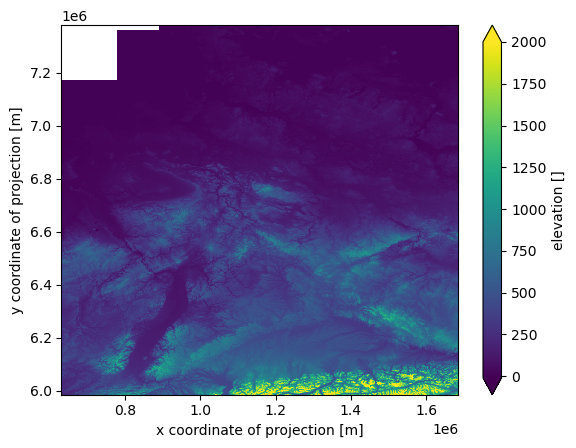

In [85]:
DE_topo_ds["elevation"].plot(vmin=-10,vmax=2000)